In [1]:
import os

os.environ.setdefault("XLA_FLAGS", "--xla_force_host_platform_device_count=12")
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


In [2]:
import matplotlib.pyplot as plt

from gwemfish.simple_pipeline import (
    _deep_merge_dict,
    make_default_cfg,
    plot_system_observation,
    setup_em_observation,
    setup_gw_observation,
    run_inference, 
    plot_posterior, 
    to_source_plane_samples, 
    plot_source_posterior,
)
#
#OUTPUT_DIR = os.path.join("examples", "outputs", "simple_pipeline_demonstration")
#os.makedirs(OUTPUT_DIR, exist_ok=True)
#print("OUTPUT_DIR:", os.path.abspath(OUTPUT_DIR))

In [3]:
from gwemfish.config import DEFAULT_KWARGS_NUMERICS, SOLVER_PARAMS
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
sample_cfg = {
    "em": {
        "pixel_grid_kwargs": {"npix": int(40), "pix_scl": 0.1},
        "psf_kwargs": {"psf_type": "GAUSSIAN", "fwhm": 0.4, "pixel_size": 0.1},#0.067
        "noise_simu_kwargs": {"npix": int(40), "background_rms": 5e-2, "exposure_time": 2200},
        "noise_inf_kwargs": {"npix": int(40), "background_rms": None, "exposure_time": 2200},
        "kwargs_numerics": DEFAULT_KWARGS_NUMERICS,
        "exposure_time": 2200,
        "seed": 87651,
        "source_pos": (0.0, 0.0), #Is this the position of the source of the GW or the position of the center of the source galaxy?
        "kwargs_source": [
            {
                "amp": 250,
                "R_sersic": 0.4,
                "n_sersic": 4.0,
                "e1": 0,
                "e2": 0,
                "center_x": 0.0, #same question for these center_x and y values
                "center_y": 0.0,
            }
        ],
        "kwargs_lens_light": [
            {
                "amp": 50.0,
                "R_sersic": 2.0,
                "n_sersic": 4.0,
                "e1": 0.0,
                "e2": 0.0,
                "center_x": 0.0,
                "center_y": 0.0,
            }
        ],
    },
    "lens": {
        "lens_model_list": ["EPL", "SHEAR"],
        "kwargs_lens": [
            {
                "theta_E": 1.2,
                "e1": 0.0,
                "e2": 0.1,
                "gamma": 2.0,
                "center_x": 0.0,
                "center_y": 0.0,
            },
            {"gamma1": 0.1, "gamma2": 0.0, "ra_0": 0.0, "dec_0": 0.0},
        ],
        "zl": 0.7,
        "zs": 1.5,
    },
    "gw": {
        "source_pos": (0.0, 0.0),
        "solver_params": SOLVER_PARAMS,
        "image_box_half_width": 10.6,
        "error_scales": {
            "sigma_td": 0.05,
            "sigma_dL_eff": 3.0,
            "epsilon": 0.005,
        },
    },
    "plot": {"plot_mode": "groupwise", "save_path": None, "save_tag": None, "hist_kwargs": {"density": True}},
    "source_plane": {"filter_std": None, "use_filtered": False},
    "output": {
        "output_dir": OUTPUT_DIR,
        "save_samples_path": None,
        "save_truths_path": None,
        "save_source_samples_path": None,
        "save_system_plot_path": None,
        "json_path": None,
    },
}

def q_pa_to_e1e2(q, pa):
    e = (1-q) / (1+q)
    e1 = float(e * np.cos(2*pa))
    e2 = float(e * np.sin(2*pa))
    return (e1, e2)

def mag_to_amp(mag_value):
    """
    convert between the apparent magnitude in the catalog to Sersic amplitude
    """
    return 60 #for now

    

In [6]:
from lenstronomy.Util import param_util
from lenstronomy.SimulationAPI.mag_amp_conversion import MagAmpConversion

In [7]:
import copy

def row_to_cfg(row, sample_cfg, gw_enabled):
    """
    Convert one row of the Qiuhan's sky catalog into a GWEMFISH configuration.

    Parameters
    ----------
    row : pandas.Series
        One row of the lens catalog.

    sample_cfg : dict
        Reference GWEMFISH config.

    Returns
    -------
    cfg : dict
        GWEMFISH configuration for this lens system.
    """

    cfg = copy.deepcopy(sample_cfg)

    # ==========================================================
    # Convert axis ratio + PA -> ellipticity
    # ==========================================================

    # --- 1. PREPARE LENS (DEFLECTOR) LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    lens_e1, lens_e2 = param_util.phi_q2_ellipticity(phi=row['deflector_pa'], q=row['deflector_q'])


    kwargs_lens_light_mag = [{
    'magnitude': row['deflector_app_mag_VIS'],
    'R_sersic': row['deflector_Re'],
    'n_sersic': 4.0,  # Standard assumption for elliptical lens galaxies
    'e1': lens_e1, 'e2': lens_e2,
    'center_x': 0, 'center_y': 0
    }]

    # --- 2. PREPARE SOURCE LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    source_e1, source_e2 = param_util.phi_q2_ellipticity(phi=row['source_pa'], q=row['source_q'])
    
    # Choose your band (e.g., VIS)
    kwargs_source_mag = [{
        'magnitude': row['source_app_mag_VIS'], 
        'R_sersic': row['source_Re'],
        'n_sersic': row['source_sersic_index'],
        'e1': source_e1, 'e2': source_e2,
        'center_x': row['source_relative_x'], 
        'center_y': row['source_relative_y']
    }]
    
    # --- 3. CONVERT BOTH TO AMP ---
    # Define your model profile types
    kwargs_model = {
        'lens_light_model_list': ['SERSIC_ELLIPSE'],
        'source_light_model_list': ['SERSIC_ELLIPSE']
    }
    
    # Initialize the converter with your survey zero-point
    mag_converter = MagAmpConversion(kwargs_model=kwargs_model, magnitude_zero_point=25.9)
    
    # Get the final dictionaries containing the calculated 'amp' keys
    lens_light_amp = mag_converter.magnitude2amplitude(kwargs_lens_light_mag=kwargs_lens_light_mag)
    source_amp = mag_converter.magnitude2amplitude(kwargs_source_mag=kwargs_source_mag)
    
    #print(lens_light_amp)
    #print(source_amp)
    
    #source_e1, source_e2 = q_pa_to_e1e2(
     #   row["source_q"],
      #  row["source_pa"],
   # )

    lens_pos = (float(row['deflector_ra']), float(row['deflector_dec']))
    
    source_pos = (float(row["source_relative_x"]), float(row["source_relative_y"]))

    # ==========================================================
    # Lens geometry
    # ==========================================================

    cfg["lens"]["zl"] = float(row["deflector_z"])
    cfg["lens"]["zs"] = float(row["source_z"])

    # ==========================================================
    # Lens mass model (EPL)
    # ==========================================================

    cfg["lens"]["kwargs_lens"][0]["theta_E"] = float(row["deflector_thetaE"])
    cfg["lens"]["kwargs_lens"][0]["gamma"] = float(row["deflector_slope"])

    cfg["lens"]["kwargs_lens"][0]["e1"] = float(lens_e1)
    cfg["lens"]["kwargs_lens"][0]["e2"] = float(lens_e2)

    cfg["lens"]["kwargs_lens"][0]["center_x"] = 0.00
    cfg["lens"]["kwargs_lens"][0]["center_y"] = 0.00

    # ==========================================================
    # External shear
    # ==========================================================

    cfg["lens"]["kwargs_lens"][1]["gamma1"] = float(row["deflector_shear1"])
    cfg["lens"]["kwargs_lens"][1]["gamma2"] = float(row["deflector_shear2"])

    cfg["lens"]["kwargs_lens"][1]["ra_0"] = 0.00
    cfg["lens"]["kwargs_lens"][1]["dec_0"] = 0.00

    # ==========================================================
    # Source light
    # ==========================================================

    cfg["em"]["kwargs_source"][0]["R_sersic"] = float(row["source_Re"])
    cfg["em"]["kwargs_source"][0]["n_sersic"] = float(row["source_sersic_index"])

    cfg["em"]["kwargs_source"][0]["e1"] = float(source_e1)
    cfg["em"]["kwargs_source"][0]["e2"] = float(source_e2)

    cfg["em"]["kwargs_source"][0]["center_x"] = source_pos[0]
    cfg["em"]["kwargs_source"][0]["center_y"] = source_pos[1]

    cfg["em"]["kwargs_source"][0]["amp"] = float(source_amp[1][0]['amp'])

    # ==========================================================
    # Lens light
    # ==========================================================

    cfg["em"]["kwargs_lens_light"][0]["R_sersic"] = float(row["deflector_Re"])
    cfg["em"]["kwargs_lens_light"][0]["n_sersic"] = float(4)

    cfg["em"]["kwargs_lens_light"][0]["e1"] = float(lens_e1)
    cfg["em"]["kwargs_lens_light"][0]["e2"] = float(lens_e2)

    cfg["em"]["kwargs_lens_light"][0]["center_x"] = 0.00
    cfg["em"]["kwargs_lens_light"][0]["center_y"] = 0.00

    cfg["em"]["kwargs_lens_light"][0]["amp"] = float(lens_light_amp[0][0]['amp'])

    # ==========================================================
    # GW source position
    # ==========================================================
    cfg["em"]["source_pos"] = source_pos
    
    if gw_enabled is True:
        cfg["gw"]["source_pos"] = (source_pos[0]+0.005, source_pos[1]-0.005)

    if gw_enabled is False:
        cfg["gw"] = {"enabled": False}

    return cfg

## Prepare to implement data

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv('../catalog/filtered_lens_catalog_PL_IC_gt_70.csv')

In [10]:
df.columns

Index(['deflector_ra', 'deflector_dec', 'deflector_z', 'deflector_q',
       'deflector_pa', 'deflector_vdisp', 'deflector_rband_abs_mag',
       'deflector_Re', 'deflector_thetaE', 'deflector_thetaE_autolens',
       'deflector_slope', 'deflector_einstein_mass', 'deflector_shear1',
       'deflector_shear2', 'source_z', 'source_max_image_multiplicity',
       'source_ra', 'source_dec', 'source_relative_x', 'source_relative_y',
       'source_pa', 'source_q', 'source_Re', 'source_sersic_index',
       'source_mStar', 'source_SFR_100', 'source_metallicity',
       'deflector_app_mag_VIS', 'source_app_mag_VIS', 'source_app_mag_F106',
       'source_app_mag_F129', 'source_app_mag_F158', 'source_app_mag_g',
       'source_app_mag_r', 'source_app_mag_i', 'source_app_mag_z', 'IC_Euclid',
       'IC_CSST', 'IC_Roman', 'IC_nofactor_Euclid', 'IC_nofactor_CSST',
       'IC_nofactor_Roman', 'origin_batch'],
      dtype='str')

### Pick a galaxy that will be the correct source and lens pair

### failing instances for EM modes (but GW-only mode is good)
- 1478 (all looks good and pretty, but PE fails)
- 917
- 1529
- 2417
- 790
- 1035 (looks very dim source and lens)
- 425 (EM inference also looks just fine, BUT too faint)


### Failing instance for GW only mode
- 1417
- 857
- 1122
- 749
- 1064

In [11]:
source_galaxy = df.iloc[39:40]

In [12]:
source_galaxy['deflector_ra']

39    5.998104
Name: deflector_ra, dtype: float64

In [13]:
source_galaxy['source_relative_y']

39   -0.107345
Name: source_relative_y, dtype: float64

In [14]:
row = source_galaxy.iloc[0]
cfg_gw_source = row_to_cfg(row, sample_cfg, True)
cfg_gw_source["use_parameter_layout"] = True

cfg_gw_source['gw']['source_pos'] = (cfg_gw_source['gw']['source_pos'][0]-0.005, cfg_gw_source['gw']['source_pos'][1]+0)

In [15]:
cfg_gw_source['gw']['source_pos']

(-0.0900745821606702, -0.11234532416476481)

In [16]:
cfg_gw_source['em']['pixel_grid_kwargs']['npix'] = 60
cfg_gw_source['em']['noise_simu_kwargs']['npix'] = 60
cfg_gw_source['em']['noise_inf_kwargs']['npix'] = 60
cfg_gw_source['em']['psf_kwargs']['fwhm'] = 0.18

In [17]:
cfg_gw_source['em']

{'pixel_grid_kwargs': {'npix': 60, 'pix_scl': 0.1},
 'psf_kwargs': {'psf_type': 'GAUSSIAN', 'fwhm': 0.18, 'pixel_size': 0.1},
 'noise_simu_kwargs': {'npix': 60,
  'background_rms': 0.05,
  'exposure_time': 2200},
 'noise_inf_kwargs': {'npix': 60,
  'background_rms': None,
  'exposure_time': 2200},
 'kwargs_numerics': {'supersampling_factor': 1},
 'exposure_time': 2200,
 'seed': 87651,
 'source_pos': (-0.0950745821606702, -0.1073453241647648),
 'kwargs_source': [{'amp': 3.49989915101762,
   'R_sersic': 0.2983537945111139,
   'n_sersic': 1.989838943525676,
   'e1': 0.01900149171785221,
   'e2': -0.46224838768227816,
   'center_x': -0.0950745821606702,
   'center_y': -0.1073453241647648}],
 'kwargs_lens_light': [{'amp': 384.0697202981292,
   'R_sersic': 0.5566352983777104,
   'n_sersic': 4.0,
   'e1': -0.12791640204209231,
   'e2': -0.24404617752198535,
   'center_x': 0.0,
   'center_y': 0.0}]}

In [18]:
ctx_gw_source = setup_em_observation(cfg=cfg_gw_source)

In [19]:
ctx_gw_source = setup_gw_observation(ctx_gw_source, cfg=cfg_gw_source)

In [22]:
from gwemfish import prune_gw_images
if len(ctx_gw_source["x_img_gw"]) > 4:
    ctx_gw_source = prune_gw_images(ctx_gw_source, n_keep=4)   # also sets ctx["cfg"]["gw"]["n_images"] = 4

In [23]:
tp = ctx_gw_source['truth_params']

In [24]:
tp

{'source_amp': 3.49989915101762,
 'source_R_sersic': 0.2983537945111139,
 'source_n': 1.989838943525676,
 'source_e1': 0.01900149171785221,
 'source_e2': -0.46224838768227816,
 'source_center_x': -0.0950745821606702,
 'source_center_y': -0.1073453241647648,
 'light_amp': 384.0697202981292,
 'light_R_sersic': 0.5566352983777104,
 'light_n': 4.0,
 'light_e1': -0.12791640204209231,
 'light_e2': -0.24404617752198535,
 'light_center_x': 0.0,
 'light_center_y': 0.0,
 'noise_sigma_bkg': 0.05,
 'x_image_true_em': Array([-6.61186032e-01,  5.62585455e-01,  5.34603835e-01, -7.41925245e-02,
         1.68481346e-10], dtype=float64),
 'y_image_true_em': Array([-5.51968647e-01,  9.24320947e-02, -1.66218001e-01,  4.93443681e-01,
         2.42306520e-10], dtype=float64),
 'lens0_gamma': 1.9861713519597728,
 'lens0_theta_E': 0.6497293723634407,
 'lens0_e1': -0.12791640204209231,
 'lens0_e2': -0.24404617752198535,
 'lens0_center_x': 0.0,
 'lens0_center_y': 0.0,
 'lens1_gamma1': -0.0060003052446307,
 'len

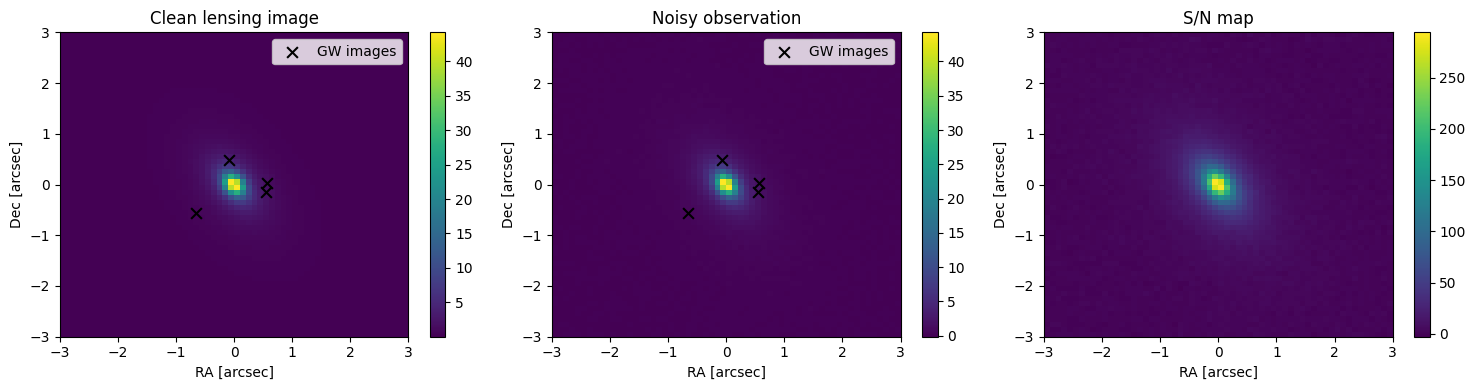

In [25]:
fig = plot_system_observation(
    ctx_gw_source,
    cfg={"output": {"save_system_plot_path": None}} #os.path.join(OUTPUT_DIR, "system_observation.png")}},
)
plt.show()

## Set up priors from catalog and Gaussian KDE

In [80]:
list_of_lens_mass = []
for i in range(len(df)):
    row = df.iloc[i]
    lens_e1, lens_e2 = param_util.phi_q2_ellipticity(phi=row['deflector_pa'], q=row['deflector_q'])
    thetaE = float(row["deflector_thetaE"])
    gamma = float(row["deflector_slope"])
    gamma1 = float(row["deflector_shear1"])
    gamma2 = float(row["deflector_shear2"])
    pair = (i, lens_e1, lens_e2, thetaE, gamma, gamma1, gamma2)
    list_of_lens_mass.append(pair)

In [25]:
e1_all = [item[1] for item in list_of_lens_mass]
e2 = [item[2] for item in list_of_lens_mass]
thetas = [item[3] for item in list_of_lens_mass]
gammas = [item[4] for item in list_of_lens_mass]
gamma1s = [item[5] for item in list_of_lens_mass]
gamma2s = [item[6] for item in list_of_lens_mass]

In [26]:
population = {'lens0_e1': e1_all, 'lens0_e2': e2, 'lens0_gamma': gammas, 'lens0_theta_E': thetas, 'lens1_gamma1': gamma1s, 'lens1_gamma2': gamma2s}

In [27]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

kde_e1 = gaussian_kde(e1_all)
kde_e2 = gaussian_kde(e2)
kde_thetaE = gaussian_kde(thetas)
kde_gamma = gaussian_kde(gammas)
kde_gamma1 = gaussian_kde(gamma1s)
kde_gamma2 = gaussian_kde(gamma2s)

In [28]:
# A version of KDEPrior class that truncates the KDE
import numpy as np
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from scipy.stats import gaussian_kde

class KDEPrior:
    def __init__(self, name, data, low=None, high=None):
        self.name = name

        # Build scipy KDE to determine the bandwidth
        kde = gaussian_kde(data)

        self.data = jnp.asarray(data)

        # 1D KDE bandwidth
        self.bandwidth = float(
            np.sqrt(kde.covariance[0, 0])
        )

        n = len(data)

        # Truncated Gaussian components
        component_dist = dist.TruncatedNormal(
            loc=self.data,
            scale=self.bandwidth,
            low=low,
            high=high
        )

        # Equivalent truncated Gaussian mixture
        self.distribution = dist.MixtureSameFamily(
            dist.Categorical(
                probs=jnp.ones(n) / n
            ),
            component_dist
        )

    def __call__(self):
        return numpyro.sample(
            self.name,
            self.distribution
        )

## Set priors

In [26]:
import numpyro.distributions as dist

In [27]:
import copy

ctx_gw_source_em = copy.deepcopy(ctx_gw_source)
ctx_gw_source_gw = copy.deepcopy(ctx_gw_source)
ctx_gw_source_both = copy.deepcopy(ctx_gw_source)

In [28]:
tp['lens0_e1']

-0.12791640204209231

In [29]:
tp['lens0_theta_E']

0.6497293723634407

In [30]:
ctx_gw_source_gw["cfg"]["priors"] = {
        "T_star": float(tp["T_star"]),
        "dL": float(tp["dL"]),
        'lens0_gamma': dist.TruncatedNormal(tp['lens0_gamma'], 0.1, low=0.001, high=5.0),
          'lens0_theta_E': dist.TruncatedNormal(tp['lens0_theta_E'], 0.1, low=0.001, high=5.0),
         #'lens0_e1': float(tp["lens0_e1"]), 
         #'lens0_e2': float(tp['lens0_e2']),
         'lens0_e1': dist.Normal(tp['lens0_e1'], 0.01),
         'lens0_e2': dist.Normal(tp['lens0_e2'], 0.01),
         'lens0_center_x': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_x']),
         'lens0_center_y': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_y']),
         #'lens1_gamma1': float(tp["lens1_gamma1"]),
         #'lens1_gamma2': float(tp["lens1_gamma2"]),
         'lens1_gamma1': dist.Normal(tp['lens1_gamma1'], 0.01),
         'lens1_gamma2': dist.Normal(tp['lens1_gamma2'], 0.01),
         'lens1_ra_0': 0.0,
         'lens1_dec_0': 0.0,
          'light0_R_sersic': float(tp["light0_R_sersic"]),
          'light0_n_sersic': float(tp["light0_n_sersic"]),
          'light0_amp': float(tp['light0_amp']),
         'light0_e1': float(tp["light0_e1"]),
         'light0_e2': float(tp["light0_e2"]),
         'light0_center_x': float(tp["light0_center_x"]),
         'light0_center_y': float(tp["light0_center_y"]),
          "noise_sigma_bkg": tp["noise_sigma_bkg"],  
        } 

In [31]:
ctx_gw_source_em["cfg"]["priors"] = {
        "T_star": float(tp["T_star"]),
        "dL": float(tp["dL"]),
        'lens0_gamma': dist.TruncatedNormal(tp['lens0_gamma'], 0.1, low=0.001, high=5.0),
          'lens0_theta_E': dist.TruncatedNormal(tp['lens0_theta_E'], 0.1, low=0.001, high=5.0),
         #'lens0_e1': float(tp["lens0_e1"]), 
         #'lens0_e2': float(tp['lens0_e2']),
         'lens0_e1': dist.Normal(tp['lens0_e1'], 0.01),
         'lens0_e2': dist.Normal(tp['lens0_e2'], 0.01),
         'lens0_center_x': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_x']),
         'lens0_center_y': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_y']),
         #'lens1_gamma1': float(tp["lens1_gamma1"]),
         #'lens1_gamma2': float(tp["lens1_gamma2"]),
         'lens1_gamma1': dist.Normal(tp['lens1_gamma1'], 0.01),
         'lens1_gamma2': dist.Normal(tp['lens1_gamma2'], 0.01),
         'lens1_ra_0': 0.0,
         'lens1_dec_0': 0.0,
          'light0_R_sersic': float(tp["light0_R_sersic"]),
          'light0_n_sersic': float(tp["light0_n_sersic"]),
          'light0_amp': float(tp['light0_amp']),
         'light0_e1': float(tp["light0_e1"]),
         'light0_e2': float(tp["light0_e2"]),
         'light0_center_x': float(tp["light0_center_x"]),
         'light0_center_y': float(tp["light0_center_y"]),
          "noise_sigma_bkg": tp["noise_sigma_bkg"],
         #'y0gw': dist.Normal(float(tp['y0gw']), f*float(tp['y0gw'])),
         #'y1gw': dist.Normal(float(tp['y1gw']), *float(tp['y1gw']))
        } 
cfg_gw_source = ctx_gw_source["cfg"]

In [ ]:
method = 'deriv-approx'
samples_gw_source_GW, truths_gw_source_GW = run_inference(
    ctx_gw_source_gw,
    mode= "GW-only", #"EM+GW",#"EM-only",#"GW-only",
    method=method,
    cfg={
        "output": {"json_tag": method},
        **({"inference": {"informed": True, "regularize": False,"num_chains": 8, "num_samples": 14500, "num_warmup": 9500}} if method == "deriv-approx" else {}),
        # "inference": {"num_chains": 12, "num_samples": 8000, "num_warmup": 8000, "n_fisher_samples": 10000},
    },
)

use_mst in probmodel: False
k_mst in keys_to_include: False
k_mst truth: None
keys_to_include: ['lens0_gamma', 'lens0_theta_E', 'lens0_e1', 'lens0_e2', 'lens1_gamma1', 'lens1_gamma2', 'image_x1', 'image_y1', 'image_x2', 'image_y2', 'image_x3', 'image_y3', 'image_x4', 'image_y4']
input_params: {'lens0_gamma': 2.065111250364708, 'lens0_theta_E': 0.6794785554586836, 'lens0_e1': -0.10524280609363186, 'lens0_e2': 0.0756592262081021, 'lens1_gamma1': -0.0369044798105458, 'lens1_gamma2': -0.0502754077004342, 'image_x1': -0.6409687988781951, 'image_y1': 0.39187320903325695, 'image_x2': 0.4528426480297992, 'image_y2': -0.5315731829319034, 'image_x3': -0.21672640245635774, 'image_y3': -0.6233567678684523, 'image_x4': 0.4433602126268594, 'image_y4': 0.41734409514011467}
Done with gradient
Done with Hessian
Running informed HMC
Hessian-informed MCMC:
  u0:            [ 2.06511125  0.67947856 -0.10524281  0.07565923 -0.03690448 -0.05027541
 -0.6409688   0.39187321  0.45284265 -0.53157318 -0.2167264 

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

ERROR:2026-08-21 15:51:40,574:jax._src.callback:442: jax.io_callback failed
Traceback (most recent call last):
  File "/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/.venv/lib/python3.13/site-packages/ipykernel/iostream.py", line 143, in _event_pipe
    event_pipe = self._local.event_pipe
                 ^^^^^^^^^^^^^^^^^^^^^^
AttributeError: '_thread._local' object has no attribute 'event_pipe'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/.venv/lib/python3.13/site-packages/tqdm/notebook.py", line 262, in update
    return super().update(n=n)
           ~~~~~~~~~~~~~~^^^^^
  File "/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/.venv/lib/python3.13/site-packages/tqdm/std.py", line 1242, in update
    self.refresh(lock_args=self.lock_args)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^

In [35]:
method = 'nautilus-source'
samples_gw_source_EM, truths_gw_source_EM = run_inference(
    ctx_gw_source_em,
    mode= "EM-only", #"EM+GW",#"EM-only",#"GW-only",
    method=method,
    cfg={
        "output": {"json_tag": method},
        **({"inference": {"informed": True, "regularize": False,"num_chains": 8, "num_samples": 14500, "num_warmup": 9500}} if method == "deriv-approx" else {}),
        # "inference": {"num_chains": 12, "num_samples": 8000, "num_warmup": 8000, "n_fisher_samples": 10000},
    },
)

  Fixed params (not sampled): ['lens0_center_x', 'lens0_center_y', 'lens1_ra_0', 'lens1_dec_0', 'light0_R_sersic', 'light0_n_sersic', 'light0_amp', 'light0_e1', 'light0_e2', 'light0_center_x', 'light0_center_y', 'noise_sigma_bkg']
Warming up EM-only log_likelihood (triggers JAX compilation)...
  warm-up log_likelihood = 5586.1170
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 37     | 2        | 4        | 107100   | N/A    | 10006 | +5563.73 


[<Figure size 1390x1390 with 36 Axes>, <Figure size 1810x1810 with 64 Axes>]

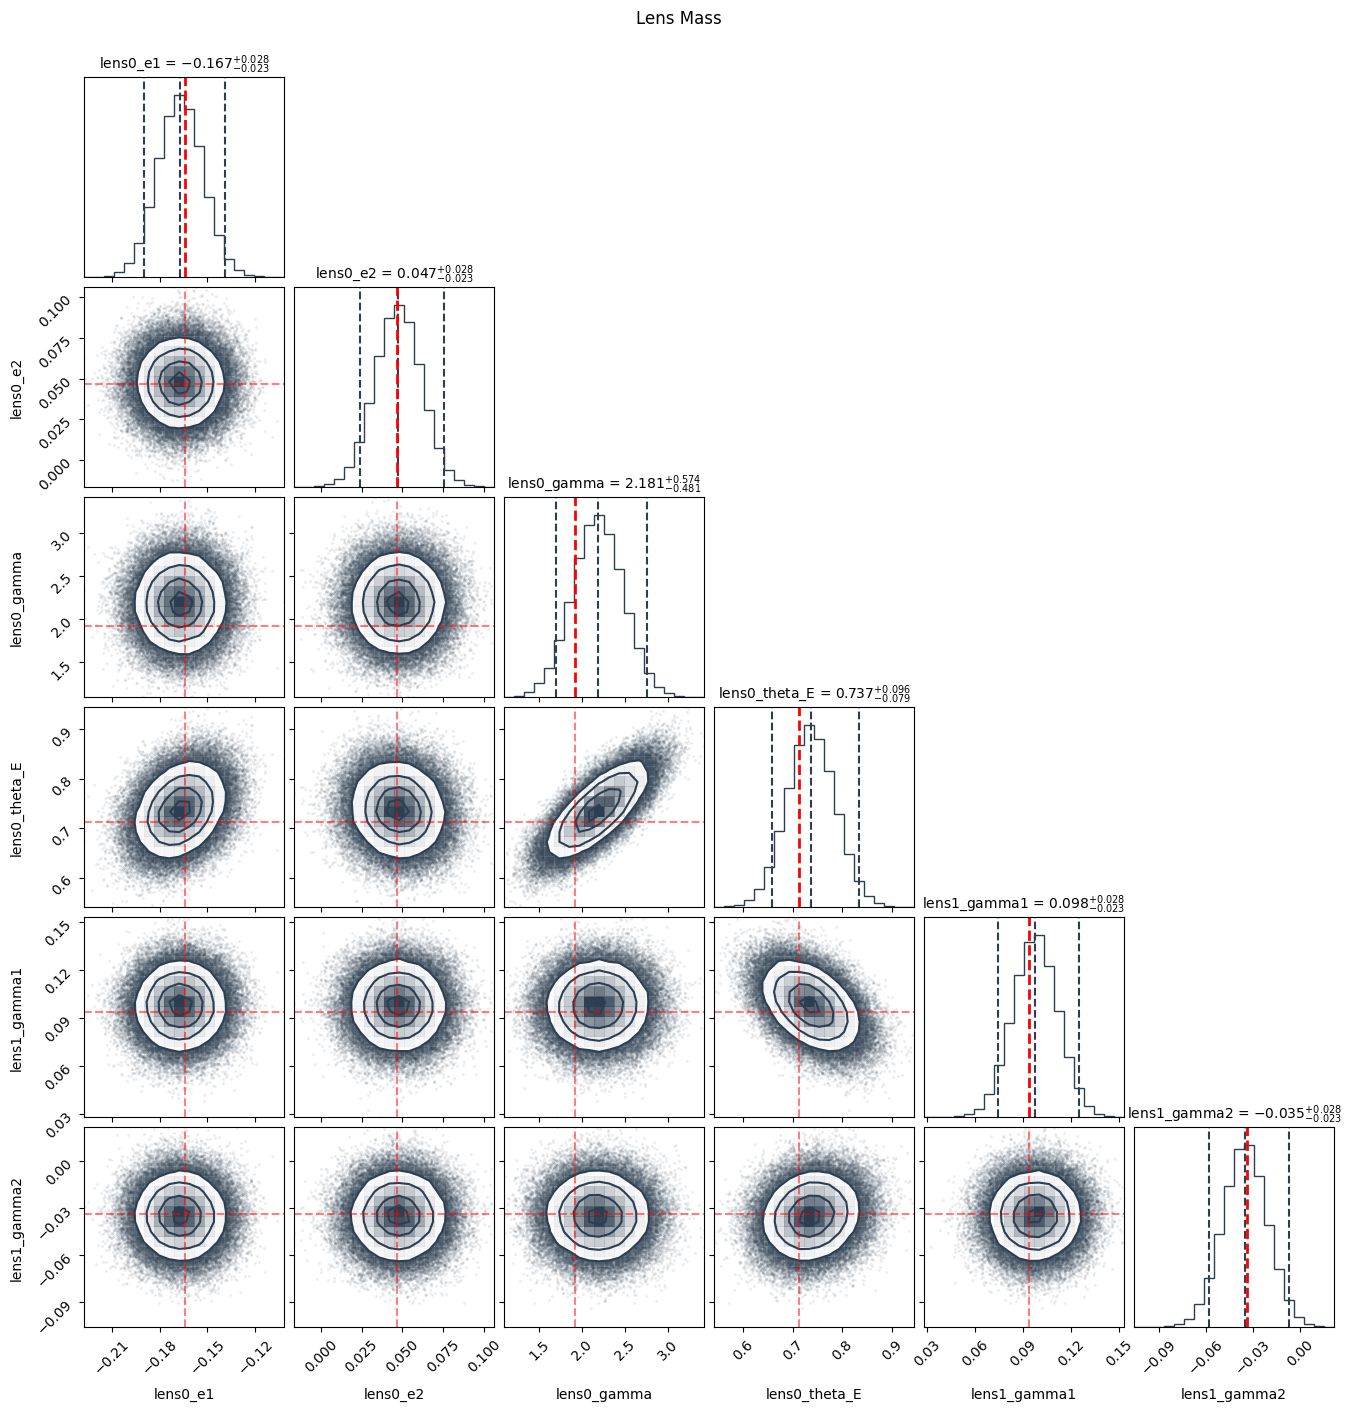

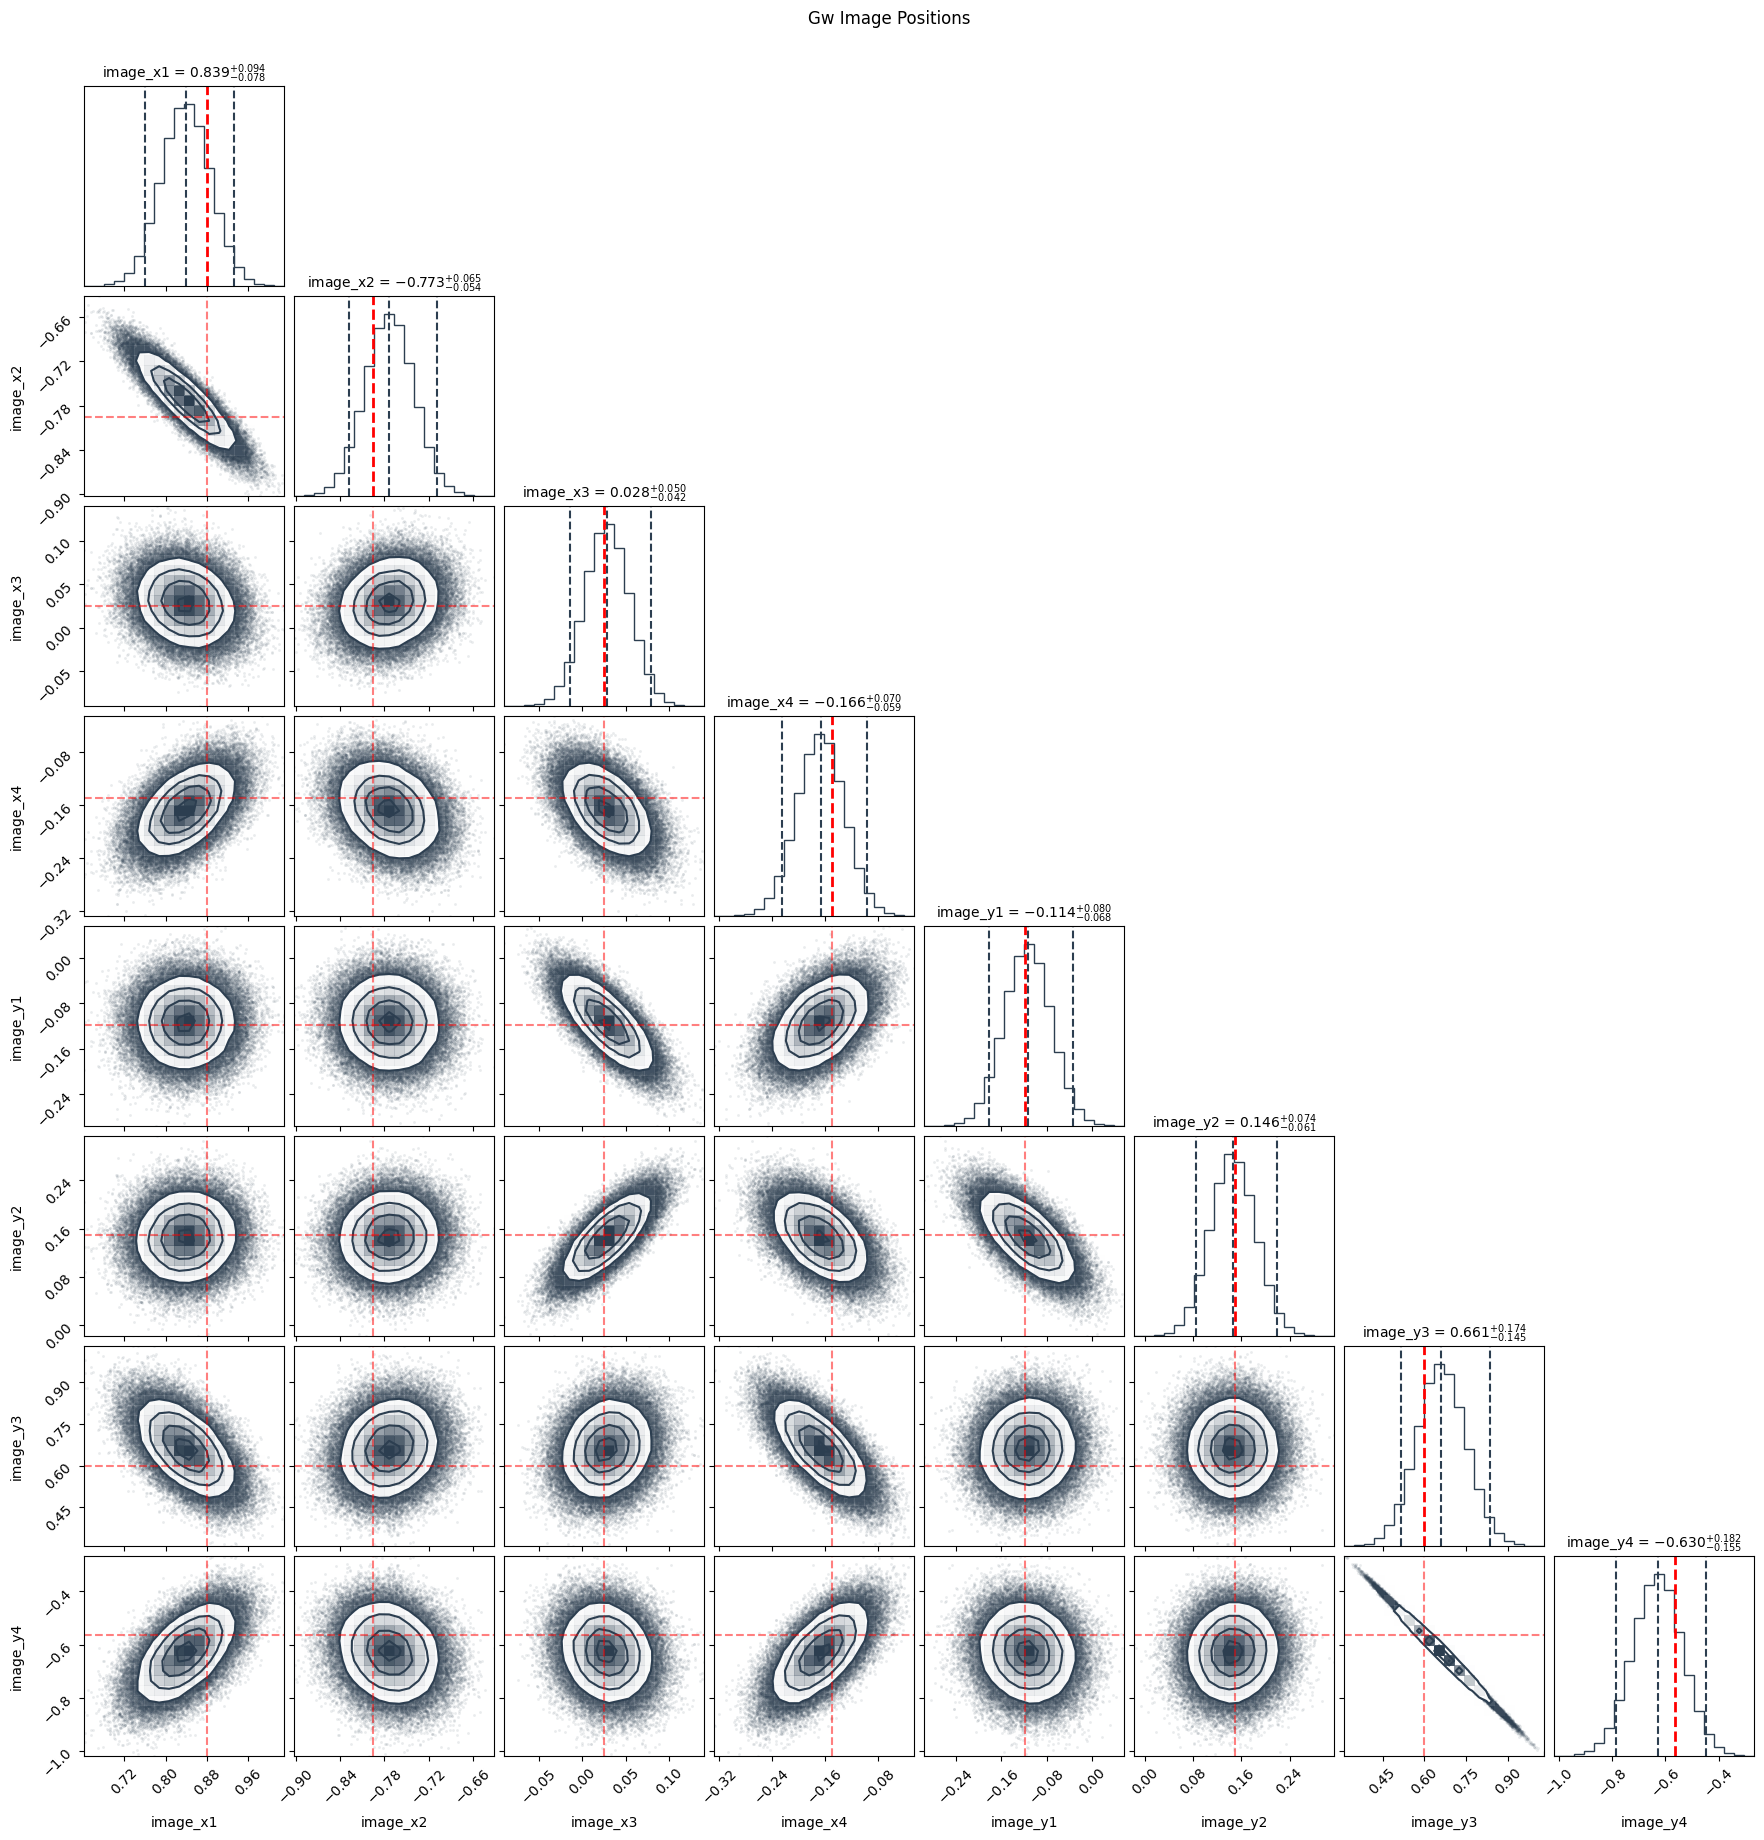

In [37]:
import corner

plot_posterior(
        samples_gw_source_GW,
        truths_gw_source_GW,
        cfg={
            "output": {"output_dir": None},
            "plot": {
                "plot_mode": "groupwise",
                "save_path": None,
            },
        },
    )

[<Figure size 1600x1600 with 49 Axes>, <Figure size 1390x1390 with 36 Axes>]

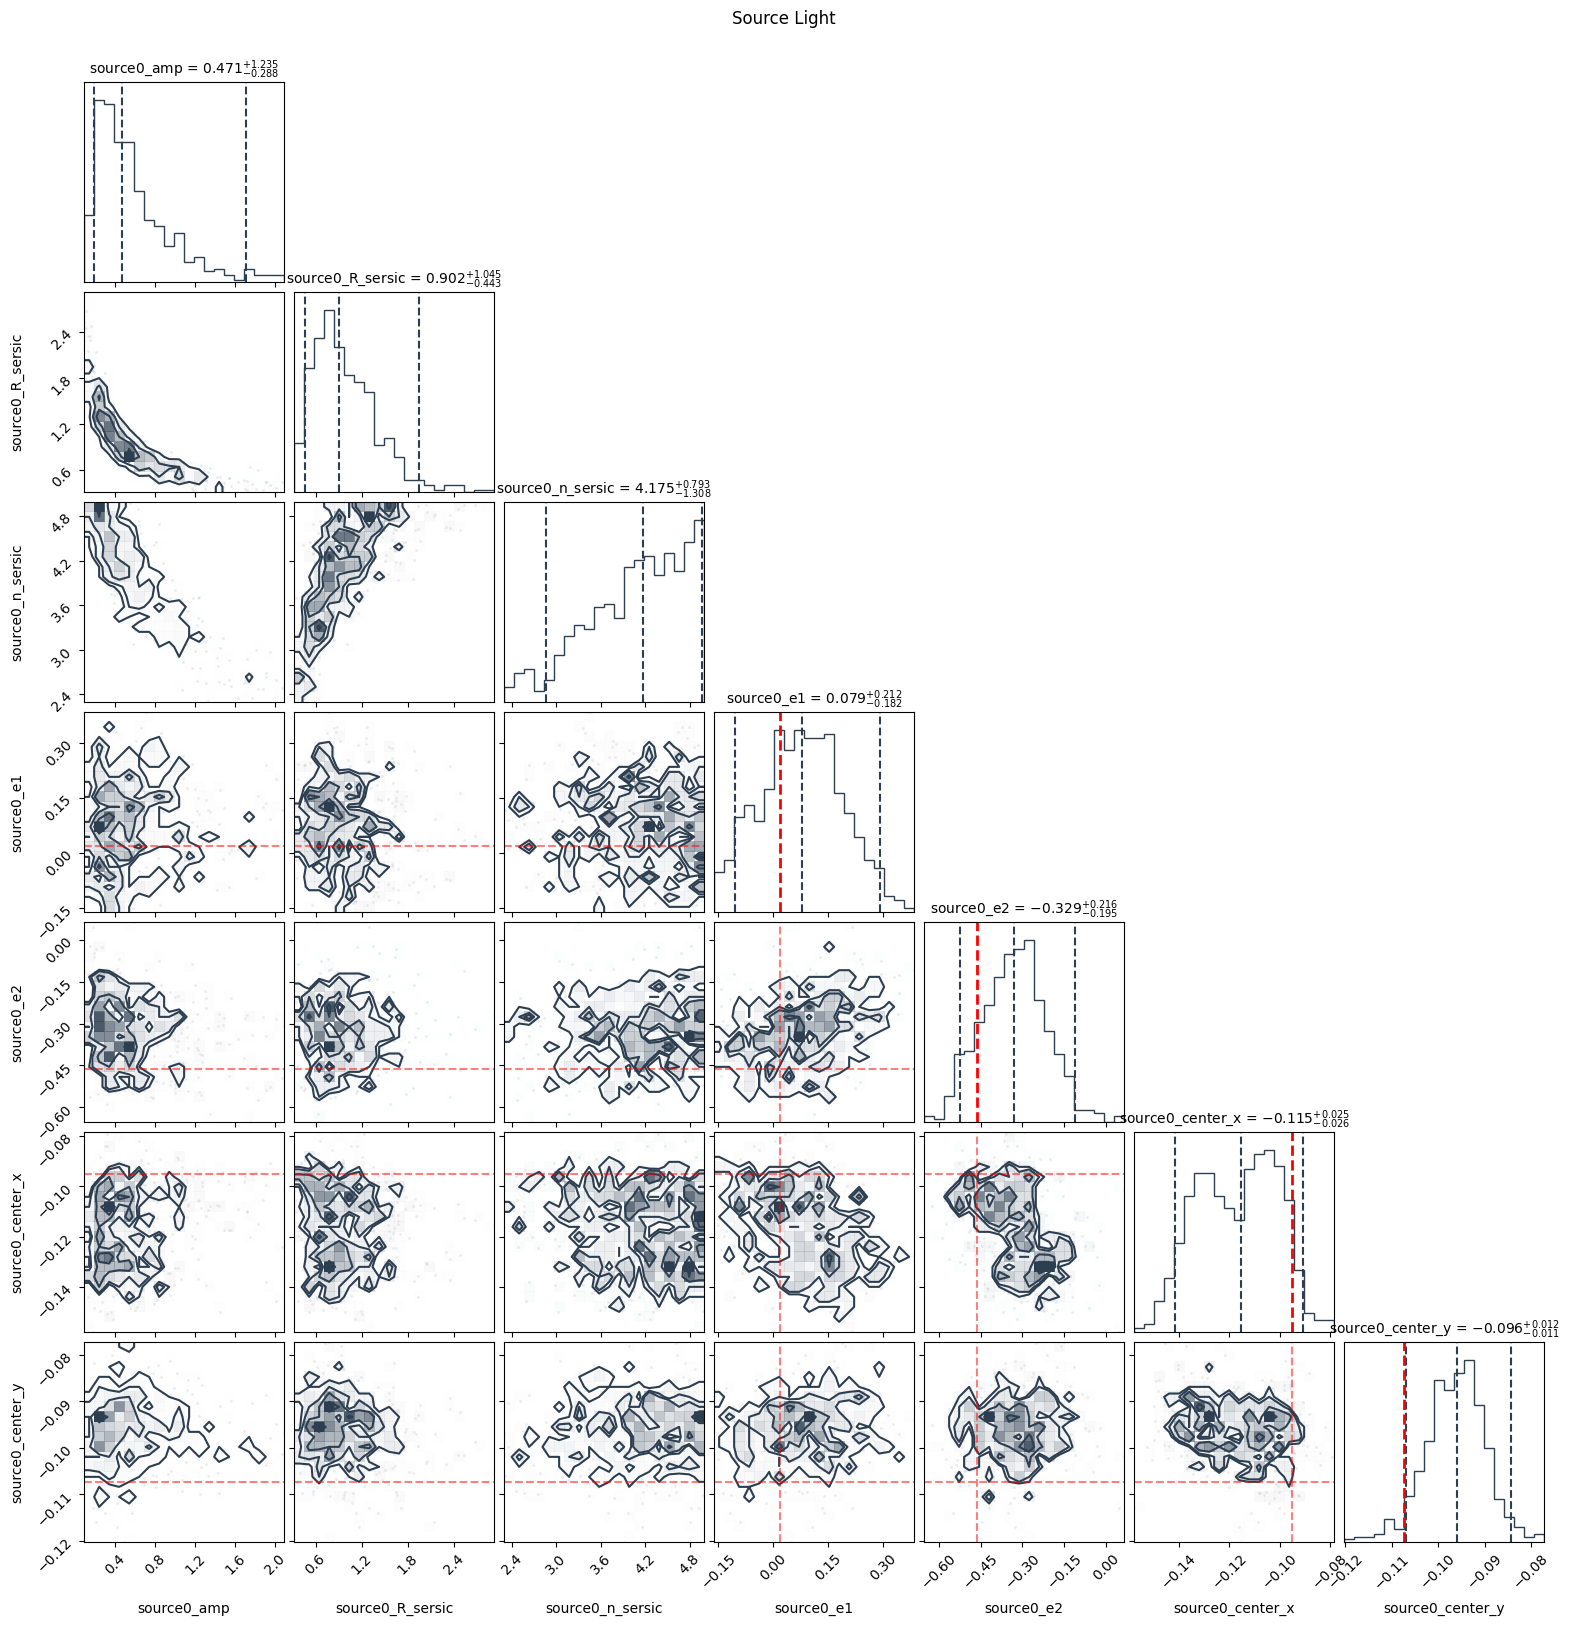

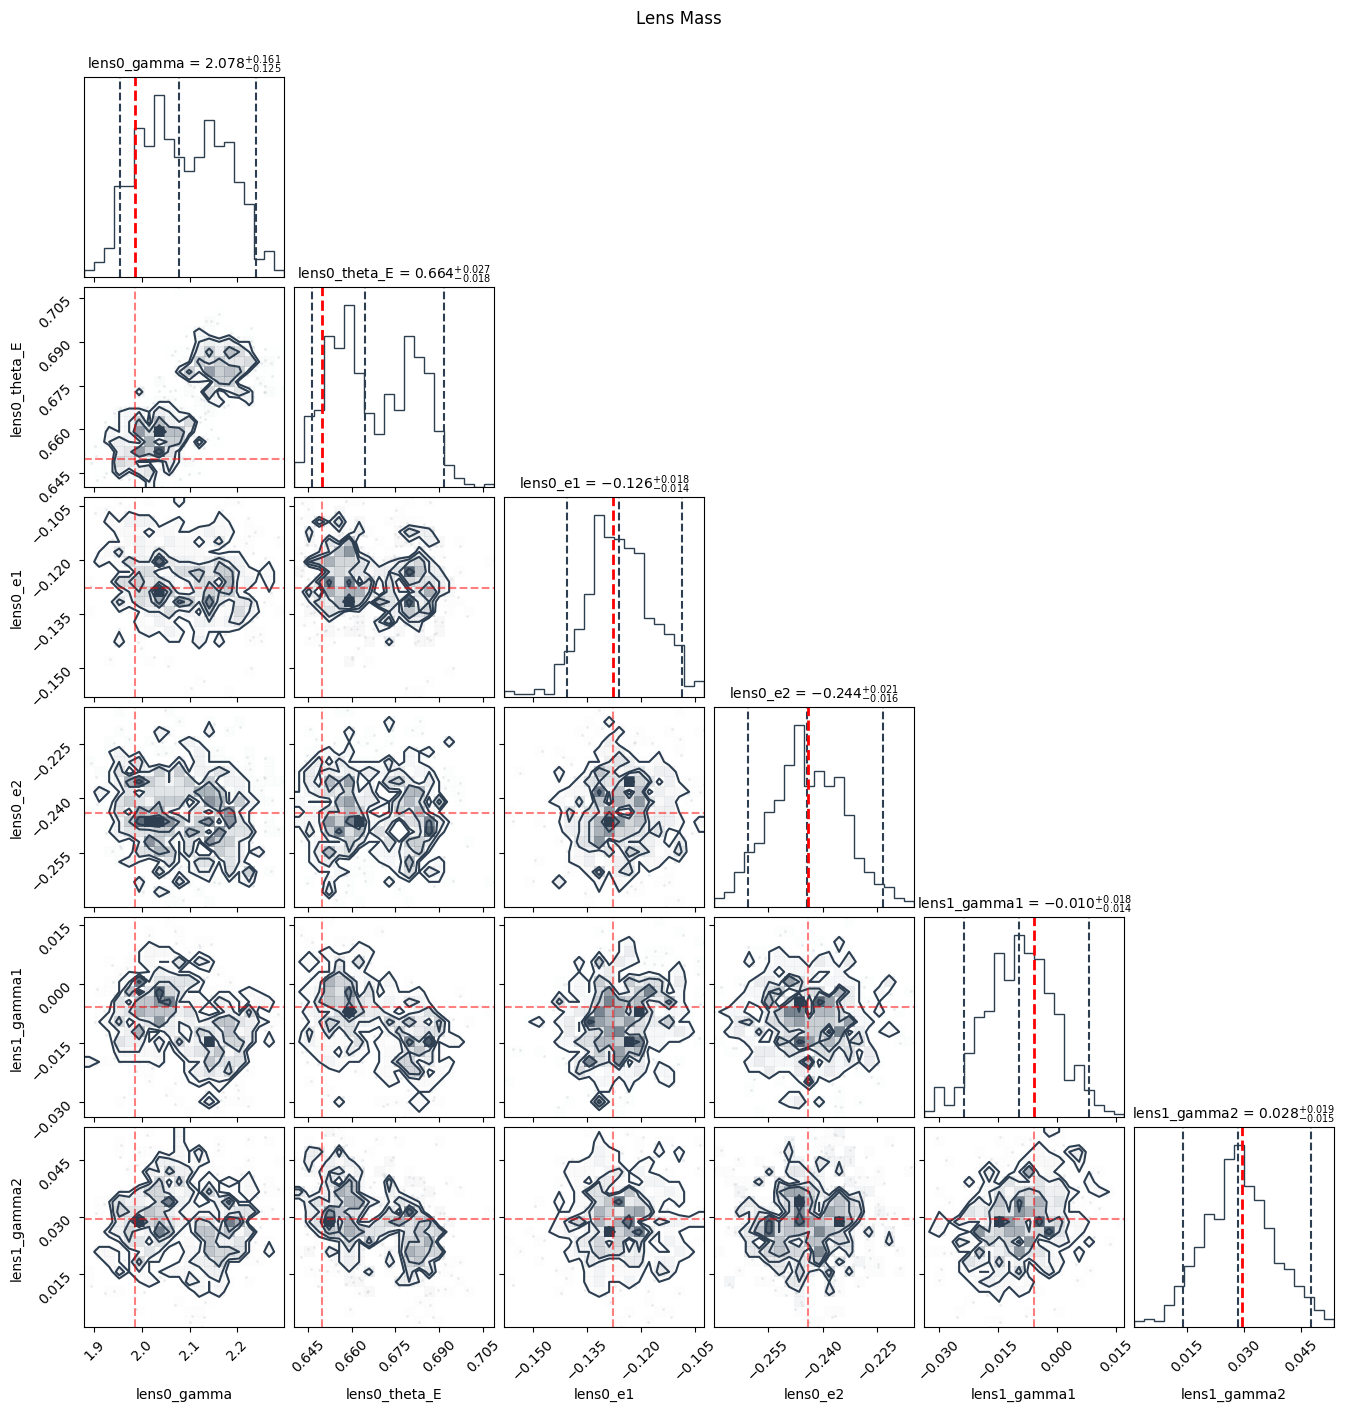

In [36]:
import corner

plot_posterior(
        samples_gw_source_EM,
        truths_gw_source_EM,
        cfg={
            "output": {"output_dir": None},
            "plot": {
                "plot_mode": "groupwise",
                "save_path": None,
            },
        },
    )

## Compute the GW only evidence

In [39]:
logp0_gw = float(ctx_gw_source_gw["fisher"]["logp0"]) #true point, 
H_gw = np.asarray(ctx_gw_source_gw["fisher"]["H0"]) # also around true point

k_gw = H_gw.shape[0]

sign_gw, logdet_gw = np.linalg.slogdet(-H_gw) #Compute the sign and (natural) logarithm of the determinant of an array.

logZ_gw = (
    logp0_gw
    + 0.5 * k_gw * np.log(2*np.pi)
    - 0.5 * logdet_gw
)

In [40]:
logZ_gw

np.float64(-121.68170747574328)

In [41]:
import jax.numpy as jnp
keys = ctx_gw_source_gw["likelihood"]["keys_to_include"]

U = jnp.column_stack([samples_gw_source_GW[k] for k in keys])

In [42]:
logdensity = ctx_gw_source_gw["likelihood"]["likelihood_function_vec"]

In [43]:
# Vectorize and JIT compile
batched_logdensity = jax.jit(jax.vmap(logdensity))

# Evaluate the log-posterior for every sample
logps_2 = batched_logdensity(U)

# Find the MAP sample
best_idx_2 = int(jnp.argmax(logps_2))

best_logp_2 = float(logps_2[best_idx_2])
best_sample_2 = U[best_idx_2]

print(f"Best sample index: {best_idx_2}")
print(f"Maximum log-posterior: {best_logp_2}")

# Convert back into a dictionary if needed
best_sample_dict_2 = {
    key: float(best_sample_2[i])
    for i, key in enumerate(keys)
}

Best sample index: 79989
Maximum log-posterior: -71.4628813706671


In [44]:
H_2 = jax.hessian(logdensity)(best_sample_2)

In [45]:
d_2 = H_2.shape[0]

sign_2, logdet_2 = jnp.linalg.slogdet(-H_2)

In [46]:
logZ_2 = (
    best_logp_2
    + 0.5 * d_2 * jnp.log(2 * jnp.pi)
    - 0.5 * logdet_2
)

print(logZ_2)

-123.38841320543635


## Compute EM only evidence

In [47]:
logp0_em = float(ctx_gw_source_em["fisher"]["logp0"]) #true point, 
H_em = np.asarray(ctx_gw_source_em["fisher"]["H0"]) # also around true point

k_em = H_em.shape[0]

sign_em, logdet_em = np.linalg.slogdet(-H_em) #Compute the sign and (natural) logarithm of the determinant of an array.

logZ_em = (
    logp0_em
    + 0.5 * k_em * np.log(2*np.pi)
    - 0.5 * logdet_em
)

In [48]:
logZ_em

np.float64(5629.913072399788)

## Computing the posterior overlap integral

In [49]:
from scipy.stats import gaussian_kde

In [50]:
shared_params = ['lens0_e1', 'lens0_e2', 'lens0_gamma', 'lens0_theta_E', 'lens1_gamma1', 'lens1_gamma2']

In [51]:
samples_matrix_GW = np.vstack([samples_gw_source_GW[p] for p in shared_params])

#defining the gaussian kde
kde_gw = gaussian_kde(samples_matrix_GW)

In [52]:
from scipy.special import logsumexp
from scipy.stats import norm

In [53]:
samples_matrix_EM = np.vstack([samples_gw_source_EM[p] for p in shared_params])

In [54]:
p_gw = kde_gw(samples_matrix_EM)

In [55]:
gamma0_samples = np.asarray(samples_gw_source_EM["lens0_gamma"])
thetaE_samples = np.asarray(samples_gw_source_EM["lens0_theta_E"])
e1_samples = np.asarray(samples_gw_source_EM["lens0_e1"])
e2_samples = np.asarray(samples_gw_source_EM["lens0_e2"])
gamma1_samples = np.asarray(samples_gw_source_EM["lens1_gamma1"])
gamma2_samples = np.asarray(samples_gw_source_EM["lens1_gamma2"])

log_prior = (
    norm.logpdf(gamma0_samples, tp['lens0_gamma'], 2.0)
    + norm.logpdf(thetaE_samples, tp['lens0_theta_E'], 0.75)
    + norm.logpdf(e1_samples, tp['lens0_e1'], 0.02)
    + norm.logpdf(e2_samples, tp['lens0_e2'], 0.02)
    + norm.logpdf(gamma1_samples, tp['lens1_gamma1'], 0.02)
    + norm.logpdf(gamma2_samples, tp['lens1_gamma2'], 0.02)
)

log_integrand = np.log(p_gw) - log_prior

log_I = logsumexp(log_integrand) - np.log(len(log_integrand))

I = np.exp(log_I)

In [56]:
log_I

np.float64(5.239581335353865)

In [57]:
I

np.float64(188.59112943675458)

In [58]:
logZ_joint = logZ_gw + logZ_em + log_I

In [59]:
logZ_joint

np.float64(5513.470946259398)